# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Raja Samudra Tandepadang
- **Email:** raja.t.padang@gmail.com
- **ID Dicoding:** rajasmdra

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

2026-07-01 05:28:29.593116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782883709.873318      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782883709.952586      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782883710.639575      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782883710.639623      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782883710.639627      58 computation_placer.cc:177] computation placer alr

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.19.0


## Data Preparation

### Data Checking

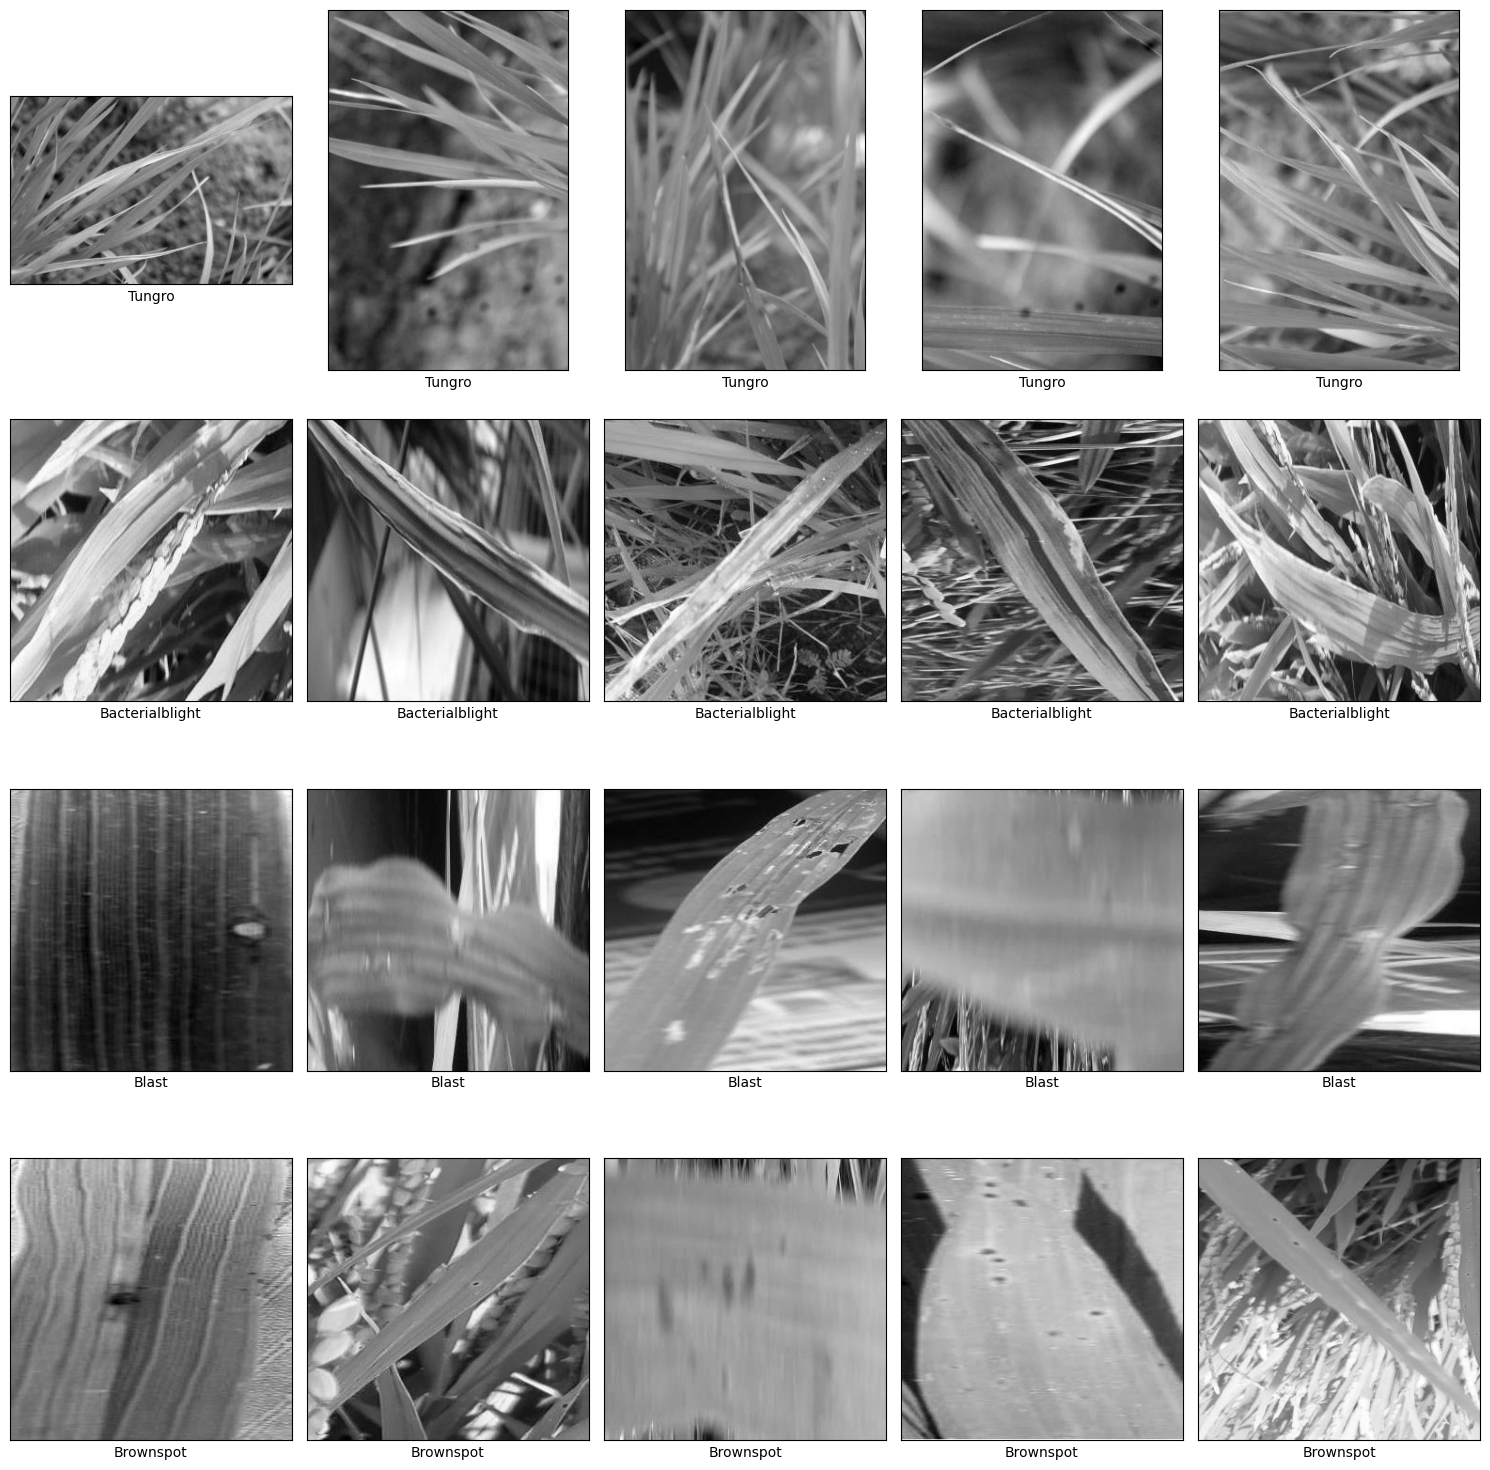

In [5]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
leaf_image = {}

# Tentukan path sumber train
path = "/kaggle/input/datasets/nirmalsankalana/rice-leaf-disease-image"
path_sub = os.path.join(path, "")
for i in os.listdir(path_sub):
    leaf_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "/kaggle/input/datasets/nirmalsankalana/rice-leaf-disease-image"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(leaf_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(leaf_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

### Plot Distribution

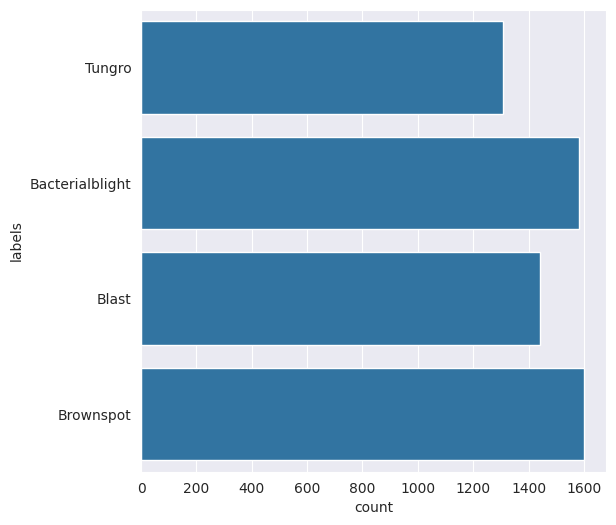

In [6]:
# Definisikan path sumber
lung_path = "/kaggle/input/datasets/nirmalsankalana/rice-leaf-disease-image"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

## Split Dataset

In [7]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= '/kaggle/input/datasets/nirmalsankalana/rice-leaf-disease-image'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

labels
Bacterialblight    1584
Blast              1440
Brownspot          1600
Tungro             1308
dtype: int64

In [8]:
X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [9]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [10]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "/kaggle/input/datasets/nirmalsankalana/rice-leaf-disease-image"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "/kaggle/working/Dataset-Final/"


set    labels         
test   Bacterialblight     327
       Blast               277
       Brownspot           314
       Tungro              269
train  Bacterialblight    1257
       Blast              1163
       Brownspot          1286
       Tungro             1039
dtype: int64 


                                                   path           labels  \
360   /kaggle/input/datasets/nirmalsankalana/rice-le...        Brownspot   
92    /kaggle/input/datasets/nirmalsankalana/rice-le...           Tungro   
5109  /kaggle/input/datasets/nirmalsankalana/rice-le...        Brownspot   
4335  /kaggle/input/datasets/nirmalsankalana/rice-le...        Brownspot   
5175  /kaggle/input/datasets/nirmalsankalana/rice-le...  Bacterialblight   

        set  
360   train  
92    train  
5109   test  
4335  train  
5175   test  


In [11]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

5932it [00:43, 135.05it/s]


## IMAGE DATA GENERATOR

In [13]:
# Definisikan direktori training dan test
TRAIN_DIR = "/kaggle/working/Dataset-Final/train/"
TEST_DIR = "/kaggle/working/Dataset-Final/test/"

train_bacterialblight = os.path.join(TRAIN_DIR + '/Bacterialblight')
train_blast = os.path.join(TRAIN_DIR + '/Blast')
train_brownspot = os.path.join(TRAIN_DIR + '/Brownspot')
train_tungro = os.path.join(TRAIN_DIR + '/Tungro')
test_bacterialblight = os.path.join(TEST_DIR + '/Bacterialblight')
test_blast = os.path.join(TEST_DIR + '/Blast')
test_brownspot = os.path.join(TEST_DIR + '/Brownspot')
test_tungro = os.path.join(TEST_DIR + '/Tungro')

print("Total number of bacterialblight images in training set: ",len(os.listdir(train_bacterialblight)))
print("Total number of blast images in training set: ",len(os.listdir(train_blast)))
print("Total number of brownspot images in training set: ",len(os.listdir(train_brownspot)))
print("Total number of tungro images in training set: ",len(os.listdir(test_tungro)))
print("Total number of bacterialblight images in test set: ",len(os.listdir(train_bacterialblight)))
print("Total number of blast images in test set: ",len(os.listdir(test_blast)))
print("Total number of brownspot images in test set: ",len(os.listdir(test_brownspot)))
print("Total number of tungro images in test set: ",len(os.listdir(test_tungro)))

Total number of bacterialblight images in training set:  1257
Total number of blast images in training set:  1163
Total number of brownspot images in training set:  1286
Total number of tungro images in training set:  269
Total number of bacterialblight images in test set:  1257
Total number of blast images in test set:  277
Total number of brownspot images in test set:  314
Total number of tungro images in test set:  269


In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (150, 150) 
BATCH_SIZE = 32

# ==============================================================================
# 1. INISIALISASI GENERATOR DENGAN STRATEGI YANG BENAR
# ==============================================================================

# Generator Train: Melakukan augmentasi + split data
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    rotation_range=20,       
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    shear_range=0.2,         
    zoom_range=0.2,          
    horizontal_flip=True,    
    fill_mode='nearest',
    validation_split=0.2
)

# Generator Validasi: HANYA rescale + split data (TANPA augmentasi acak)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Generator Test: Murni rescale dari folder terpisah
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================================================================
# 2. ALIRKAN GAMBAR KE MASING-MASING GENERATOR
# ==============================================================================

# A. Data Train (Menggunakan train_datagen agar kaya akan variasi gambar)
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR, 
    target_size=IMAGE_SIZE,          
    batch_size=BATCH_SIZE,
    class_mode='categorical',        
    subset='training',
    shuffle=True
)

# B. Data Validation (Menggunakan val_datagen agar gambarnya mulus/asli)
val_generator = val_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=IMAGE_SIZE,          
    batch_size=BATCH_SIZE,
    class_mode='categorical',        
    subset='validation',
    shuffle=False
)

# C. Data Test (Murni mengambil dari folder eksternal TEST_DIR)
test_generator = test_datagen.flow_from_directory(
    directory=TEST_DIR,  
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==============================================================================
# 3. VERIFIKASI ARRAY HASIL KONVERSI
# ==============================================================================
print("\n--- Hasil Verifikasi ---")
x_batch, y_batch = next(train_generator)
print("Bentuk Array Gambar (Batch, Tinggi, Lebar, Saluran Warna):", x_batch.shape)
print("Bentuk Array Label:", y_batch.shape)

Found 3798 images belonging to 4 classes.
Found 947 images belonging to 4 classes.
Found 1187 images belonging to 4 classes.

--- Hasil Verifikasi ---
Bentuk Array Gambar (Batch, Tinggi, Lebar, Saluran Warna): (32, 150, 150, 3)
Bentuk Array Label: (32, 4)


## Modelling

In [15]:
tf.keras.backend.clear_session()

model_1 = Sequential()

# Layer 1
model_1.add(Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Layer 2
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Layer 3
model_1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# ========================= Fully Connected Layers =========================
model_1.add(Flatten())
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.5))

# Output Layer (4 Kelas)
model_1.add(Dense(4, activation='softmax'))

# ========================= COMPILE MODEL =========================
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-01 05:31:59.216380: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,351,460 (5.16 MB)

 Trainable params: 1,351,236 (5.15 MB)

 Non-trainable params: 224 (896.00 B)

None


In [16]:
# ========================= CALLBACKS (Kunci Grafik Stabil) =========================
# Otomatis menurunkan learning rate jika val_loss mandek
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# Otomatis stop training jika model mulai overfitting parah
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

# ========================= TRAINING =========================
# Catatan: class_weight dihapus karena data kamu sudah balance
history_1 = model_1.fit(
    train_generator,
    epochs=20,
    batch_size=32,
    validation_data=val_generator,
    callbacks=[reduce_lr, early_stop]  # Pasang pengaman di sini
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 91s 736ms/step - accuracy: 0.6027 - loss: 1.0483 - val_accuracy: 0.2186 - val_loss: 3.7534 - learning_rate: 1.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 717ms/step - accuracy: 0.7285 - loss: 0.7060 - val_accuracy: 0.2788 - val_loss: 3.1898 - learning_rate: 1.0000e-04
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 724ms/step - accuracy: 0.7620 - loss: 0.6195 - val_accuracy: 0.6241 - val_loss: 1.0331 - learning_rate: 1.0000e-04
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 88s 735ms/step - accuracy: 0.7780 - loss: 0.5657 - val_accuracy: 0.8416 - val_loss: 0.4709 - learning_rate: 1.0000e-04
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 87s 731ms/step - accuracy: 0.8044 - loss: 0.5224 - val_accuracy: 0.9050 - val_loss: 0.2925 - learning_rate: 1.0000e-04
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 89s 744ms/step - accuracy: 0.8062 - loss: 0.5008 - val_accuracy: 0.8849 - val_loss: 0.2931 - learning_rate: 1.0000e-04
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 87s 72

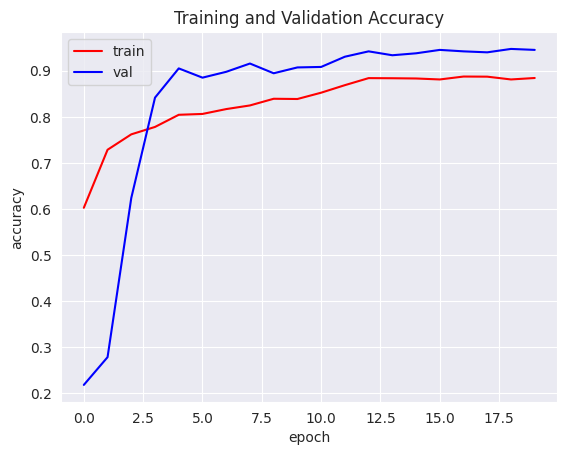

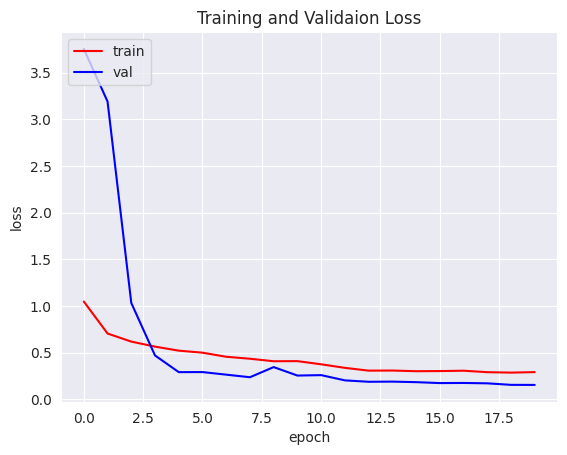

In [17]:
## Evaluasi dan Visualisasi

acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
 
plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

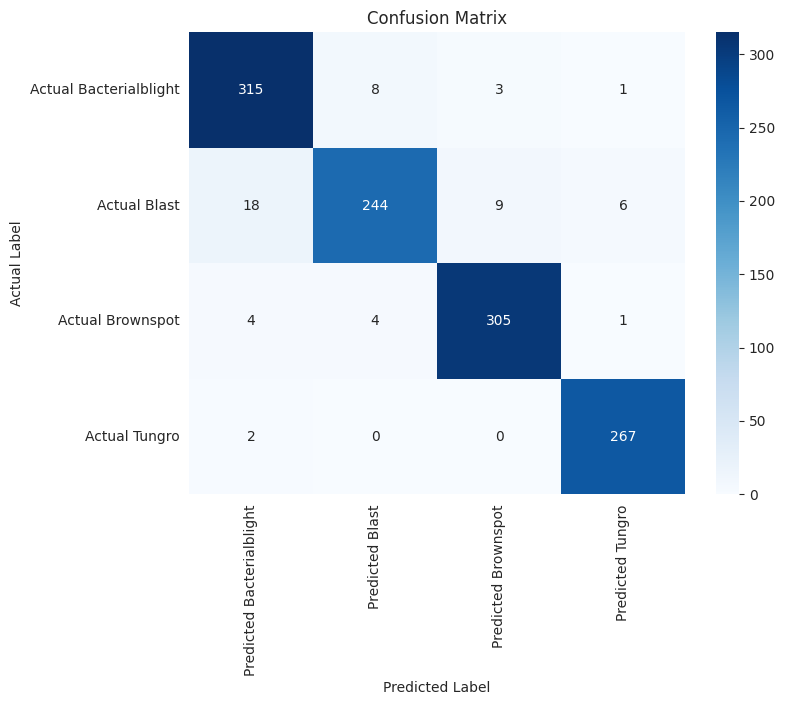


=== Classification Report ===
                 precision    recall  f1-score   support

Bacterialblight     0.9292    0.9633    0.9459       327
          Blast     0.9531    0.8809    0.9156       277
      Brownspot     0.9621    0.9713    0.9667       314
         Tungro     0.9709    0.9926    0.9816       269

       accuracy                         0.9528      1187
      macro avg     0.9538    0.9520    0.9525      1187
   weighted avg     0.9530    0.9528    0.9524      1187



In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Reset generator agar membaca dari gambar pertama
test_generator.reset()

# 2. Lakukan prediksi
preds_1 = model_1.predict(test_generator, verbose=0)

# 3. Ambil indeks kelas dengan probabilitas tertinggi (Multi-class)
preds_1_classes = np.argmax(preds_1, axis=1)

# 4. Membuat Confusion Matrix dengan label kolom 'Predicted'
target_names = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']

cm = pd.DataFrame(
    data=confusion_matrix(y_true=test_generator.classes, y_pred=preds_1_classes, labels=[0, 1, 2, 3]),
    index=[f"Actual {name}" for name in target_names],
    columns=[f"Predicted {name}" for name in target_names]
)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# 5. Print Classification Report
print("\n=== Classification Report ===")
print(classification_report(
    y_true=test_generator.classes,
    y_pred=preds_1_classes,
    target_names=target_names,
    digits=4
))

## Konversi Model

### Saved Model

In [19]:
save_path = '/kaggle/working/saved_model/'
model_1.export(save_path)

INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


Saved artifact at '/kaggle/working/saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139806420001104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420002448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420001488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420003216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806419999376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420000720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420003408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420004368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420004752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139806420005904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

### TF-Lite

In [20]:
import os
import tensorflow as tf

# 1. Buat folder 'tflite' terlebih dahulu agar sesuai format submission
folder_tflite = '/kaggle/working/tflite/'
if not os.path.exists(folder_tflite):
    os.makedirs(folder_tflite)

# 2. PROSES KONVERSI TF LITE
converter = tf.lite.TFLiteConverter.from_saved_model('/kaggle/working/saved_model/')
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Mengaktifkan kuantisasi agar file ringan di HP
tflite_model = converter.convert()
 
# Simpan file model.tflite ke dalam folder tflite/
save_path_tflite = os.path.join(folder_tflite, 'model.tflite')
with tf.io.gfile.GFile(save_path_tflite, 'wb') as f:
    f.write(tflite_model)

print(f"File model.tflite tersimpan di: {save_path_tflite}")


# 3. PROSES PEMBUATAN LABEL.TXT
# Tulis nama kelas penyakit daun padi sesuai urutan indeks modelmu
labels = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
save_path_label = os.path.join(folder_tflite, 'label.txt')

# Tulis ke file teks (satu baris untuk satu nama kelas)
with open(save_path_label, 'w') as f:
    for label in labels:
        f.write(label + '\n')

print(f"File label.txt tersimpan di: {save_path_label}")

File model.tflite tersimpan di: /kaggle/working/tflite/model.tflite
File label.txt tersimpan di: /kaggle/working/tflite/label.txt


W0000 00:00:1782885861.793859      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782885861.793975      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1782885861.812651      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


### TFJS

In [21]:
# Install library tfjs converter
!pip install tensorflowjs --quiet

# Menjalankan perintah CLI converter bawaan TFJS langsung dari sel notebook
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_node_names='Identity' \
    --saved_model_tags=serve \
    /kaggle/working/saved_model/ \
    /kaggle/working/tfjs_model/

print("-> Sukses! Folder tfjs_model berhasil dibuat.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 79.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.55.1 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.5.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you 